# Diffusion Limited Aggregation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#note, this function expects a matrix A[ix,iy]
#and then displays so that A[:,0] is the lowest row of pixels
def display(A):
    # shape: dimensions of an array
    # shape[0]: dimension of row
    maxX = A.shape[0]
    # shape[1]: dimension of column
    maxY = A.shape[1]
    # Buat array 2D isi 0 smua, dengan jumlah row: maxY dan jumlah column: maxX
    B = np.zeros((maxY, maxX))
    # Loop dari index 0 sampai maxX-1
    for ix in range(0,maxX):
        # Loop dari index 0 sampai maxY-1
        for iy in range(0,maxY):
            # Contoh iterasi pertama:
            # B[maxY-1-0, 0] = A[0, 0]
            # B[maxY-1-1, 0] = A[0, 1]
            # B[maxY-1-2, 0] = A[0, 2] ....
            # B[maxY-1-maxY+1, 0] = A[0, maxY-1] -> B[0, 0] = A[0, maxY-1]
            # Jadi bisa disimpulkan pengisian value ke B dimulai dari row paling bawah (maxY-1) sampai ke atas (0)
            # Ketika kolom 0 sudah terisi semua, loop iy selesai dan kembali ke loop pertama dengan ix=1, lanjut isi kolom 1 dari bawah
            B[maxY-1-iy,ix] = A[ix,iy]

    #Display the graphics outside of the notebook.
    #On a PC, use '%matplotlib qt' instead.
    # %matplotlib osx
    # %matplotlib qt
    %matplotlib inline

    plt.rcParams['figure.figsize'] = [6, 6/maxX*maxY]
    plt.imshow(B);
    plt.axis('off');
    plt.show()
    plt.draw()
    plt.pause(0.01)

In [3]:
nParticles = 10000
maxX = 200
maxY = 100

In [4]:
# Initialize matrix containing all 2D grid points A(x,y)
# 0 <= x < maxX
# 0 <= y < maxY
# A(x,y)=0 ... site is empty
# A(x,y)>0 ... site is filled
# Hasil: A matrix dengan dimensi baris 200 dan dimensi kolom 100
A = np.zeros((maxX, maxY))

# Introduce a sticky wall at the bottom
# by filling the lowest row of pixels with particles
A[:,0] = 1
print(A.transpose())

[[1. 1. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


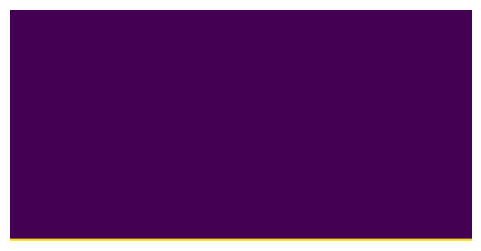

<Figure size 600x300 with 0 Axes>

In [5]:
#test the display routine
display(A)

In [6]:
# To save computer time, we want to inject the new particle not too far
# above growing aggregate. We inject at on a line 'yStart', which
# keeps being increased so that it is always 'yBuffer' lines above the
# highest structure
yBuffer = 5
yStart  = 1 + yBuffer

2. First please write the code for the diffusion step. Depending on the random value, r, please
have the moving particle go left, right, up, or down each with a 25% probability. Add 7 to 10 lines
of code here
3. Right below in the file apply periodic boundary conditions in x direction. If the particle has left
the simulation cell on the left, let it reappear on the right, and vice versa.
4. In the following section, your need to determine whether any of the four neighboring sites are
filled. The variables xp, xm, yp, and ym are defined for your convenience. Again apply periodic
boundary conditions to xm and xp. Can you think of a reason why we do not have to worry about
periodic boundary conditions in Y direction?
5. Run the code and see what happens.
6. The code will stop earlier than anticipated because there is not enough space to accommodate
10,000 particles. Please increase maxX and maxY until there is sufficient space for all of them.
7. The growing dendrites compete for new particles like trees compete for sunlight. Not all
dendrites make it. So please make incremental adjustments to maxX and maxY so there is just one
surviving tree when the last of the 10,000 particles has been attached. This completes part I.

i= 0 	x=127 	y=1 	yStart=6


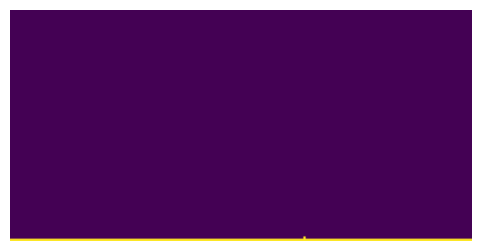

<Figure size 600x300 with 0 Axes>

i= 1000 	x=195 	y=7 	yStart=19


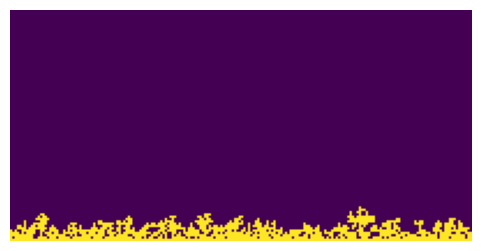

<Figure size 600x300 with 0 Axes>

i= 2000 	x=180 	y=13 	yStart=28


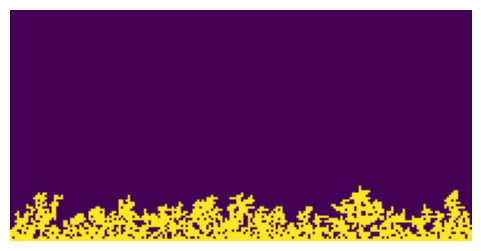

<Figure size 600x300 with 0 Axes>

i= 3000 	x=9 	y=24 	yStart=37


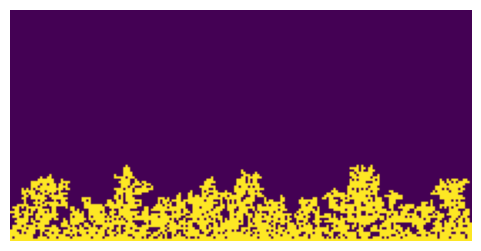

<Figure size 600x300 with 0 Axes>

i= 4000 	x=43 	y=39 	yStart=51


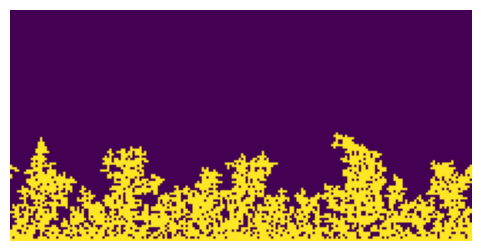

<Figure size 600x300 with 0 Axes>

i= 5000 	x=40 	y=40 	yStart=61


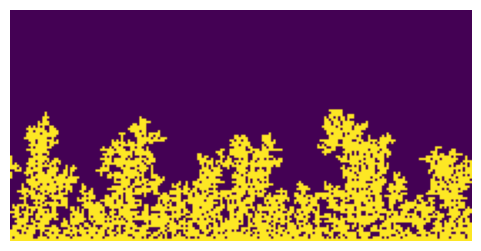

<Figure size 600x300 with 0 Axes>

i= 6000 	x=84 	y=39 	yStart=73


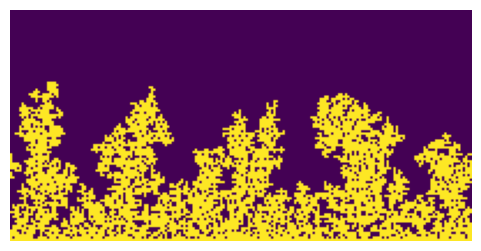

<Figure size 600x300 with 0 Axes>

i= 7000 	x=24 	y=65 	yStart=84


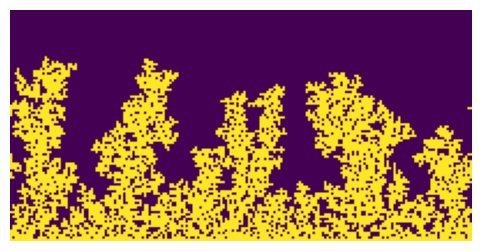

<Figure size 600x300 with 0 Axes>

Structures reached Y limit after only 7943 particles


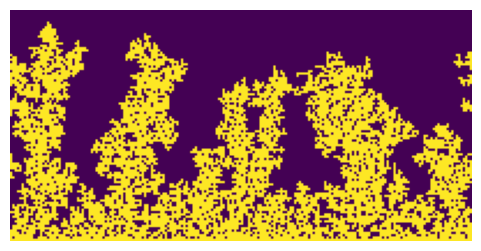

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

In [7]:
# mulai dari 0 sampai 9999
for i in range(0,nParticles):
    # Compute new starting point on the line y=yStart
    # Pilih sebuah koordinat horizontal secara acak antara 0 sampai 199
    x  = np.random.randint(0,maxX)
    # Pilih sebuah koordinat vertikal dengan nilai 6
    y  = yStart; #always start at upper limit

    while True:
      # Simpan posisi sekarang (original)
        xOrg = x
        yOrg = y

        r = np.random.random(); # Random float:  0.0 <= r < 1.0
        #based on the value of 'r', move the particle
        #left, right, up, or down and change x and y accordingly
        # Bagian ini random, jadi pokoknya dibagi 4 dalam probability nya
        # Setiap kali loop berjalan, partikel memiliki peluang yang adil
        # (sama besar) untuk melangkah ke salah satu dari empat arah tersebut.
        # Jika angka acak di antara 0-0.25, partikel bergerak ke Kanan
        if (r <= .25):
        # if (r <= .2):
          x += 1
        # Jika di antara 0.25-0.50, partikel bergerak ke Kiri
        elif (r > .25 and r <= .5):
        # elif (r > .2 and r <= .5):
          x -= 1
        # Jika di antara 0.50-0.75, partikel bergerak ke Atas
        elif (r > .5 and r <= .75):
          y += 1
        # Jika di antara 0.75-1.0, partikel bergerak ke Bawah
        elif (r > .75):
          y -= 1

        #now apply periodic boundary conditions to 'x'
        # Ini mencegah partikel hilang atau menyebabkan error saat mencoba mengakses indeks matriks yang tidak ada (out of bounds).
        # Skenario 1: cell jalan ke kiri
        # Ini kalo x sudah meninggalkan simulation cell (nilai minus krn jalan ke kiri terus) -> dioper ke kanan (maxX-1)
        if (x < 0):
          x = maxX-1
        # Skenario 2: cell jalan ke kanan
        # Ini kalo x sudah mencapai maksimum (sama dengan nilai max) -> dioper ke kiri (x=0)
        if (x == maxX):
          x = 0
        # Pengecekan tabrakan & batas atas
        # A[x,y] == 1: Jika posisi baru yang baru saja dipindah ternyata sudah ditempati partikel lain (nilai sudah berubah ke 1)
        # y > yStart: Jika partikel melayang terlalu jauh ke atas (melewati garis start)
        if (A[x,y] == 1 or y>yStart):
            # Jika salah satu kondisi di atas terpenuhi, partikel dikembalikan ke posisi sebelumnya
            # (xOrg, yOrg) dan loop diulang lagi untuk mencoba arah gerak yang berbeda.
            x = xOrg
            y = yOrg
            continue; # if this site has been taken try moving in a different direction

        #determine the x coordinates of the left and right neighbors
        #store them in 'xm' and 'xp' and apply periodic boundary conditions again
        # (x-plus): Koordinat di sebelah kanan.
        xp = x + 1
        # (x-minus): Koordinat di sebelah kiri.
        xm = x - 1
        # (y-plus): Koordinat di sebelah atas.
        yp = y + 1
        # (y-minus): Koordinat di sebelah bawah.
        ym = y - 1

        # Jika tetangga kanan berada di luar batas kanan (maxX),
        # tetangga diubah menjadi 0 (paling kiri)
        if (xp == maxX):
          xp = 0
        # Jika tetangga kiri berada di luar batas kiri (minus),
        # tetangga diubah menjadi maxX-1 (paling kanan)
        if (xm < 0):
          xm = maxX-1
        # Jika tetangga atas berada di luar batas atas (maxY),
        # tetangga diubah menjadi 0 (paling bawah)
        if (yp == maxY):
          yp = 0
        # Jika tetangga bawah berada di luar batas bawah (minus),
        # tetangga diubah menjadi maxY-1 (paling atas)
        if (ym < 0):
          ym = maxY-1

        # Determine if any neighboring site is occupied
        # if that is the case, enter the following 'if' clause
        # angka acak dari 0.0 sampai 1.0
        m = np.random.random()
        # peluang 3% bagi sebuah partikel untuk menempel jika hanya ada satu tetangga
        p = 0.03
        # Skenario: Partikel saat ini berada di sebuah kotak yang dikepung oleh partikel lain di
        # keempat sisinya (Kanan xp, Kiri xm, Atas yp, dan Bawah ym).
        if (A[xp,y]==1 and A[xm,y]==1 and A[x,yp]==1 and A[x,ym]==1):
          # Peluang menempelnya diperbesar menjadi 4 * p (yaitu 0.12 atau 12%).
          # Semakin banyak tetangga sekitar, semakin besar kemungkinan partikel itu menempel.
          if (m <= 4*p):
            # Partikel menempel -> ubah ke 1
            A[x,y] = 1
            # apakah posisi menempelnya (y) berada dekat dengan batas atas (yStart)
            if (y+yBuffer>yStart and y+yBuffer<maxY):
                # yStart akan dinaikkan agar partikel berikutnya muncul lebih tinggi lagi
                # supaya pohon DLA bisa terus tumbuh ke atas
                yStart = y+yBuffer

            # print kondisi setiap kelipatan 1000
            if (i%1000==0):
                print(f'i= {i} \tx={x} \ty={y} \tyStart={yStart}')

            # kondisinya sama spt di atas, kalo i%1000 == 0, visualisasikan!
            nNewParticlesPerFrame = 1000
            if (i%nNewParticlesPerFrame==0):
                display(A)

            # Begitu partikel dinyatakan menempel (A[x,y] = 1), kita harus menghentikan
            # loop while True (gerak acak) untuk partikel tersebut dan lanjut ke
            # iterasi for berikutnya untuk memasukkan partikel baru.
            break # particle was attached, break out of current loop and insert next one

        # Seluruh kondisi di bawah menyimpulkan:
        # Semakin banyak tetangga yang bersentuhan,
        # semakin besar kemungkinan partikel itu berhenti bergerak dan menempel.

        # Jika hasilnya 3, berarti partikel tersebut sedang 'terjepit' di & hanya menyisakan satu sisi terbuka.
        # Berarti ada 3 tetangga yang 'mengepung'
        elif (A[xp,y] + A[xm,y] + A[x,yp] + A[x,ym] == 3):
          # Karena ada 3 tetangga yang menyentuh, peluang menempelnya menjadi 3 * 0.03 = 0.09 (9%).
          if (m <= 3*p):
            A[x,y] = 1
            if (y+yBuffer>yStart and y+yBuffer<maxY):
              yStart = y+yBuffer
            if (i % 1000 == 0):
              print(f'i= {i} \tx={x} \ty={y} \tyStart={yStart}')
            nNewParticlesPerFrame = 1000
            if (i % nNewParticlesPerFrame == 0):
              display(A)
            break

        # Kondisi dengan 2 tetangga yang menyentuh
        elif (A[xp,y] + A[xm,y] + A[x,yp] + A[x,ym] == 2):
          # Peluang menempelnya adalah 2 * 0.03 = 0.06 (6%)
          if (m <= 2*p):
            A[x,y] = 1
            if (y+yBuffer>yStart and y+yBuffer<maxY):
              yStart = y+yBuffer
            if (i % 1000 == 0):
              print(f'i= {i} \tx={x} \ty={y} \tyStart={yStart}')
            nNewParticlesPerFrame = 1000
            if (i % nNewParticlesPerFrame == 0):
              display(A)
            break

        # Kondisi terakhir: minimal ada 1 tetangga yang menyentuh
        elif (A[xp,y]==1 or A[xm,y]==1 or A[x,yp]==1 or A[x,ym]==1):
          # Menggunakan peluang dasar p = 0.03 (3%).
          # Ini adalah cara paling umum bagaimana 'cabang' baru mulai tumbuh pada struktur DLA.
          if (m <= p):
            A[x,y] = 1
            if (y+yBuffer>yStart and y+yBuffer<maxY):
                yStart = y+yBuffer

            if (i%1000==0):
                print(f'i= {i} \tx={x} \ty={y} \tyStart={yStart}')

            nNewParticlesPerFrame = 1000
            if (i%nNewParticlesPerFrame==0):
                display(A)
            break

    # yStart akan terus naik setiap kali pohon DLA tumbuh lebih tinggi
    # oleh karena itu, cek apakah yStart sudah menyentuh batas atas (maxY)
    # kalau sudah, berarti tidak ada lagi ruang bagi partikel baru untuk muncul
    # kalau tidak ada pengecekan ini, akan terjadi error out of bounds
    if (yStart+1==maxY):
        print(f'Structures reached Y limit after only {i} particles')
        break

display(A)
plt.savefig("DLA10000.png")